# Սրտի հիվանդության կանխատեսում — Դասակարգման նախագիծ (Project-Synced)

**Առարկա:** Մեքենայական ուսուցում 

**Տվյալների հավաքածու:** UCI Cleveland Heart Disease Dataset (`data/heart_disease.csv`)

**Աղբյուր:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/heart+disease)

**Խնդրի տեսակ:** Երկուական **Classification** — կանխատեսել՝ արդյոք հիվանդն ունի՞ սրտի հիվանդություն (`target > 0` -> 1)

Այս notebook-ը թարմացված է այնպես, որ preprocessing-ը, feature engineering-ը և model evaluation-ը համընկնեն `train.py`-ի հետ։

## Բովանդակություն
1. Գրադարանների ներմուծում
2. Տվյալների բեռնում և մաքրում (train.py-ի տրամաբանությամբ)
3. Տվյալների ուսումնասիրություն և նախապատրաստում
4. Պարտադիր մոդելներ — Logistic Regression, KNN
5. Լրացուցիչ մոդելներ — Random Forest, Gradient Boosting
6. Համեմատություն, ROC/AUC, Cross-validation, GridSearchCV
7. Եզրակացություններ

## 1. Գրադարանների ներմուծում

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
DATA_PATH = Path("data") / "heart_disease.csv"

print("Գրադարանները հաջողությամբ ներմուծվեցին։")
print(f"Օգտագործվող տվյալների ուղին: {DATA_PATH}")

Գրադարանները հաջողությամբ ներմուծվեցին։
Օգտագործվող տվյալների ուղին: data\heart_disease.csv


In [33]:
import joblib

# Բեռնում ենք scaler-ը models թղթապանակից
scaler = joblib.load('models/scaler.joblib')

# Ստուգում ենք՝ արդյոք հաջողությամբ բեռնվեց
print("Scaler-ը հաջողությամբ բեռնվեց!")
print(scaler)

Scaler-ը հաջողությամբ բեռնվեց!
StandardScaler()


## 2. Տվյալների բեռնում

Տվյալները վերցված են **UCI Machine Learning Repository**-ից (Cleveland Heart Disease dataset)։ Ֆայլն ունի 14 սյունակ՝

| Սյունակ | Նկարագրություն |
|---------|----------------|
| `age` | Տարիք |
| `sex` | Սեռ (1=արական, 0=իգական) |
| `cp` | Կրծքավանդակի ցավի տեսակ (1-4) |
| `trestbps` | Հանգստի արյան ճնշում (mm Hg) |
| `chol` | Խոլեստերին (mg/dl) |
| `fbs` | Արյան շաքար > 120 mg/dl (1=այո) |
| `restecg` | Հանգստի ԷՍԳ արդյունք (0-2) |
| `thalach` | Առավելագույն զարկերակ |
| `exang` | Ֆիզ. ծանրաբեռնումից անգինա (1=այո) |
| `oldpeak` | ST depression |
| `slope` | ST segment-ի թեքություն |
| `ca` | Ֆտորոսկոպիայով ներկված անոթների քանակ |
| `thal` | Թալասեմիա (3/6/7) |
| `target` | **Ախտորոշում** (0=հիվանդություն չկա, 1+=կա) |

In [3]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print("Raw shape:", df_raw.shape)
df.head()

Raw shape: (544, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Տվյալների ուսումնասիրություն և նախապատրաստում

### 3.1 Տողերի և սյունակների քանակը

In [4]:
print(f"Տողեր:     {df.shape[0]}")
print(f"Սյունակներ: {df.shape[1]}")

Տողեր:     544
Սյունակներ: 14


### 3.2 Յուրաքանչյուր սյունակի տվյալի տիպը

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 544 entries, 0 to 543
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       544 non-null    str  
 1   sex       544 non-null    str  
 2   cp        544 non-null    str  
 3   trestbps  544 non-null    str  
 4   chol      544 non-null    str  
 5   fbs       544 non-null    str  
 6   restecg   544 non-null    str  
 7   thalach   544 non-null    str  
 8   exang     544 non-null    str  
 9   oldpeak   544 non-null    str  
 10  slope     544 non-null    str  
 11  ca        544 non-null    str  
 12  thal      544 non-null    str  
 13  target    544 non-null    str  
dtypes: str(14)
memory usage: 59.6 KB


`ca` և `thal` սյունակները պահվում են որպես տեքստ (`object`), քանի որ նախնական ֆայլում որոշ արժեքների փոխարեն `?` կա։ Վերածում ենք թվայինի, `?`-ները դառնում են `NaN`։

In [6]:
df = df_raw.copy()

# train.py-ի նման՝ թվայնացում, որպեսզի կոտրված/header-like տողերը դառնան NaN
numeric_cols = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target",
]
for col in [c for c in numeric_cols if c in df.columns]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

duplicate_count = int(df.duplicated().sum())
print(f"Կրկնվող տողեր: {duplicate_count} (պահպանում ենք, ինչպես train.py-ում)")

before = len(df)
df.dropna(subset=["target"], inplace=True)
print(f"target-ի սխալ/բացակայող արժեքներով հեռացված տողեր: {before - len(df)}")

for col in ["ca", "thal"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

before2 = len(df)
df.dropna(inplace=True)
print(f"մնացած missing-ներով հեռացված տողեր: {before2 - len(df)}")

# Binarize target (0=առողջ, 1=հիվանդ)
df["target"] = (df["target"] > 0).astype(int)

print("Տիպերն ուղղումից հետո՝")
print(df[["ca", "thal", "target"]].dtypes)
print("\nԹիրախի բաշխվածություն:")
print(df["target"].value_counts())
print(f"\nՄաքրված տվյալների shape: {df.shape}")

Կրկնվող տողեր: 240 (պահպանում ենք, ինչպես train.py-ում)
target-ի սխալ/բացակայող արժեքներով հեռացված տողեր: 1
մնացած missing-ներով հեռացված տողեր: 0
Տիպերն ուղղումից հետո՝
ca        float64
thal      float64
target      int64
dtype: object

Թիրախի բաշխվածություն:
target
0    297
1    246
Name: count, dtype: int64

Մաքրված տվյալների shape: (543, 14)


### 3.3 Վիճակագրական ամփոփ տվյալներ (միջին, մեծագույն, percentile-ներ)

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000
mean,54.370166,0.679558,3.163904,131.744015,248.646409,0.151013,1.036832,150.151013,0.335175,1.048435,1.600368,0.670350,4.731123,0.453039
std,8.982414,0.467077,0.953158,17.814202,52.000250,0.358392,0.995621,22.747921,0.472487,1.162384,0.619903,0.946924,1.944215,0.498249
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,212.000000,0.000000,0.000000,135.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,244.000000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,277.000000,0.000000,2.000000,166.500000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


**Վիճակագրության կարճ մեկնաբանություն**
- Տարիքային միջակայքը և սրտային հիմնական ցուցանիշները նորմալ բժշկական միջակայքերում են, բայց կան նաև ռիսկային բարձր արժեքներ։
- `chol`-ի բաշխվածությունը լայն է, դրա համար outlier ստուգումը կարևոր է։
- `target`-ի բաշխվածությունը չափավոր հավասարակշիռ է, ուստի Accuracy/F1 համադրությամբ գնահատումը տեղին է։
- Քանի որ preprocessing-ը նույնն է, ինչ train.py-ում, notebook-ի արդյունքները համադրելի են script-ի արդյունքների հետ։

### 3.4 Թիրախի բաշխվածությունը

target
0    297
1    246
Name: count, dtype: int64

target
0    54.7 %
1    45.3 %
Name: proportion, dtype: str


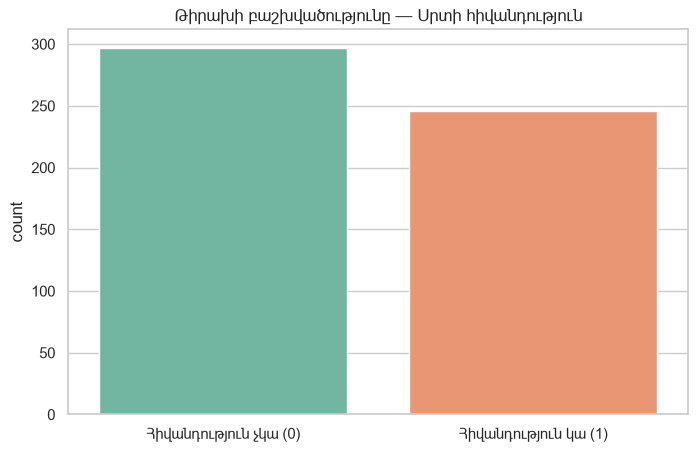

In [7]:
print(df["target"].value_counts())
print()
print((df["target"].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

ax = sns.countplot(data=df, x="target", hue="target",
                   palette="Set2", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Հիվանդություն չկա (0)", "Հիվանդություն կա (1)"])
ax.set_title("Թիրախի բաշխվածությունը — Սրտի հիվանդություն")
ax.set_xlabel("")
plt.show()

Տվյալները **գրեթե հավասարակշիռ** են (54% հիվանդ / 46% առողջ), ինչը բարենպաստ է մոդելի ուսուցման համար — accuracy-ն ևս հուսալի չափանիշ կլինի, ի տարբերություն ծայրահեղ անհավասարակշիռ տվյալների։

### 3.5 Բացակայող արժեքների ստուգում

In [8]:
missing = df.isna().sum()
print("Բացակայող արժեքներ ըստ սյունակի:")
print(missing[missing > 0])
print(f"\nՀամախառն բացակայող արժեք: {df.isna().sum().sum()}")

Բացակայող արժեքներ ըստ սյունակի:
Series([], dtype: int64)

Համախառն բացակայող արժեք: 0


`ca`-ն ու `thal`-ը կարող են ունենալ բացակայող արժեքներ (`?`)։ Դրանք լրացնում ենք մեդիանով՝ train.py-ի նույն մոտեցմամբ։

Կարևոր է. train.py-ի նման, կրկնվող տողերը չենք ջնջում, որպեսզի pipeline-ը լիովին համընկնի script-ի հետ։

In [9]:
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

print("Բացակայող արժեքները լրացնելուց հետո:", df.isna().sum().sum())

Բացակայող արժեքները լրացնելուց հետո: 0


### 3.6 Կորելացիան սյունակների միջև

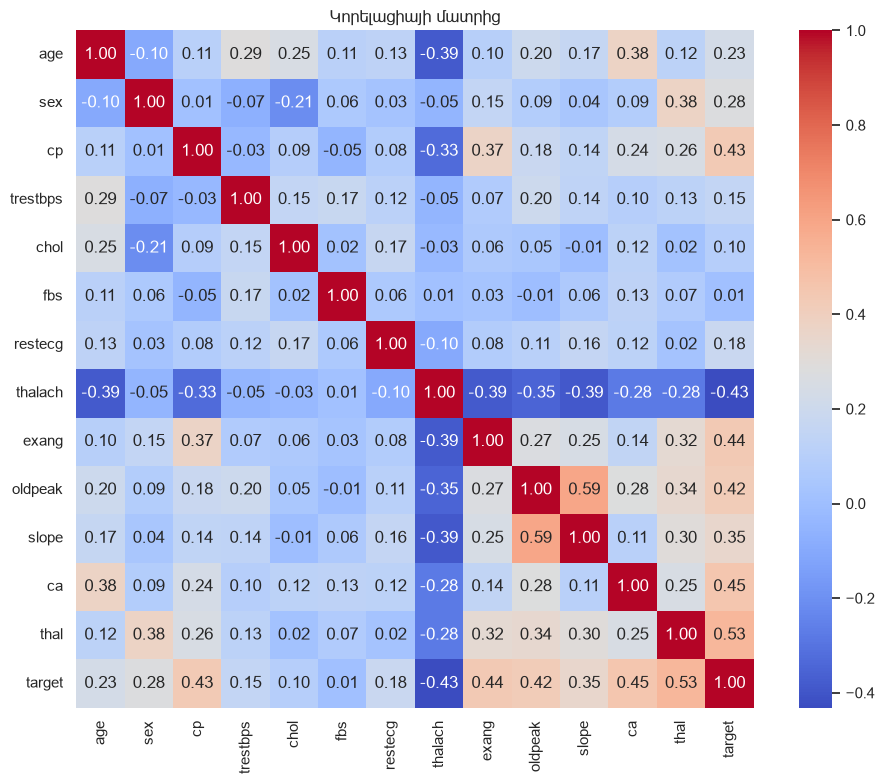

In [10]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Կորելացիայի մատրից")
plt.tight_layout()
plt.show()

**Կորելացիայի եզրահանգումներ**
- `cp` (կրծքի ցավ) և `thalach` (առավ. զարկ.) ուժեղ **դրական** կորելացիա ունեն հիվանդության հետ — բարձր ցուցանիշ = ավելի հիվանդ։
- `exang` (ֆիզ. ծանրաբ. անգինա), `oldpeak` (ST depression) և `ca` (ներկ. անոթ) **բացասական** — բարձր = ավելի հիվանդ (inverse coding)։
- `age` չափավոր դրական կորելացիա ունի — ավելի տարեց = ավելի հիվանդ, բայց ոչ ամենաուժեղ գործոնը։

### 3.7 Տեսողական ուսումնասիրություն

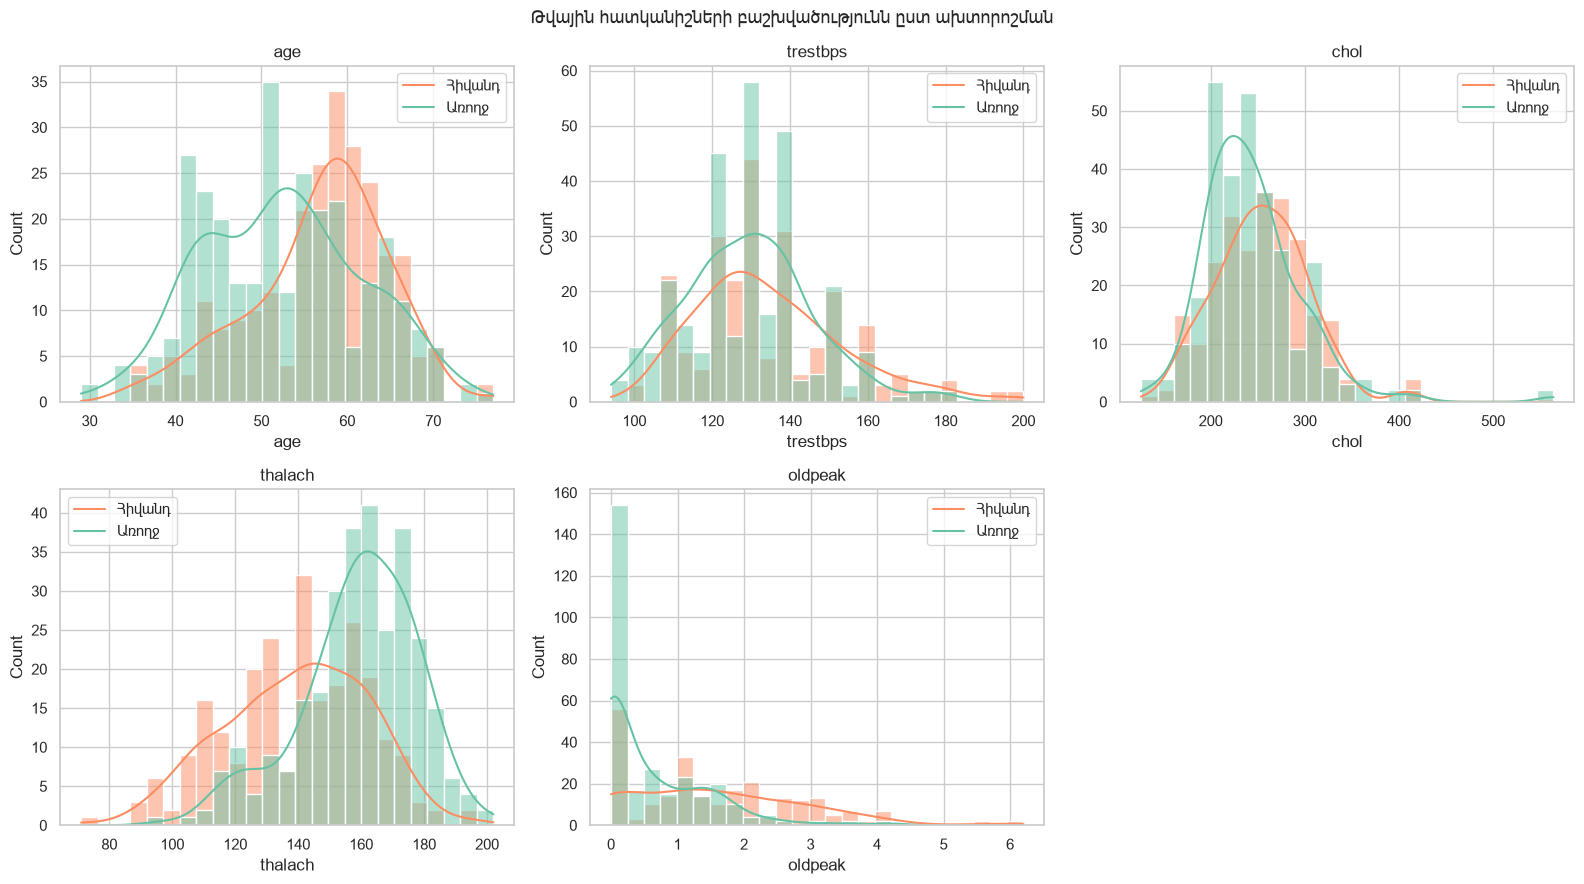

In [11]:
# Թվային հատկանիշները ըստ հիվանդության
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=col, hue="target", kde=True, bins=25,
                 ax=ax, palette="Set2")
    ax.set_title(f"{col}")
    ax.legend(["Հիվանդ", "Առողջ"], title="")
axes.ravel()[-1].set_visible(False)
plt.suptitle("Թվային հատկանիշների բաշխվածությունն ըստ ախտորոշման", fontsize=13)
plt.tight_layout()
plt.show()

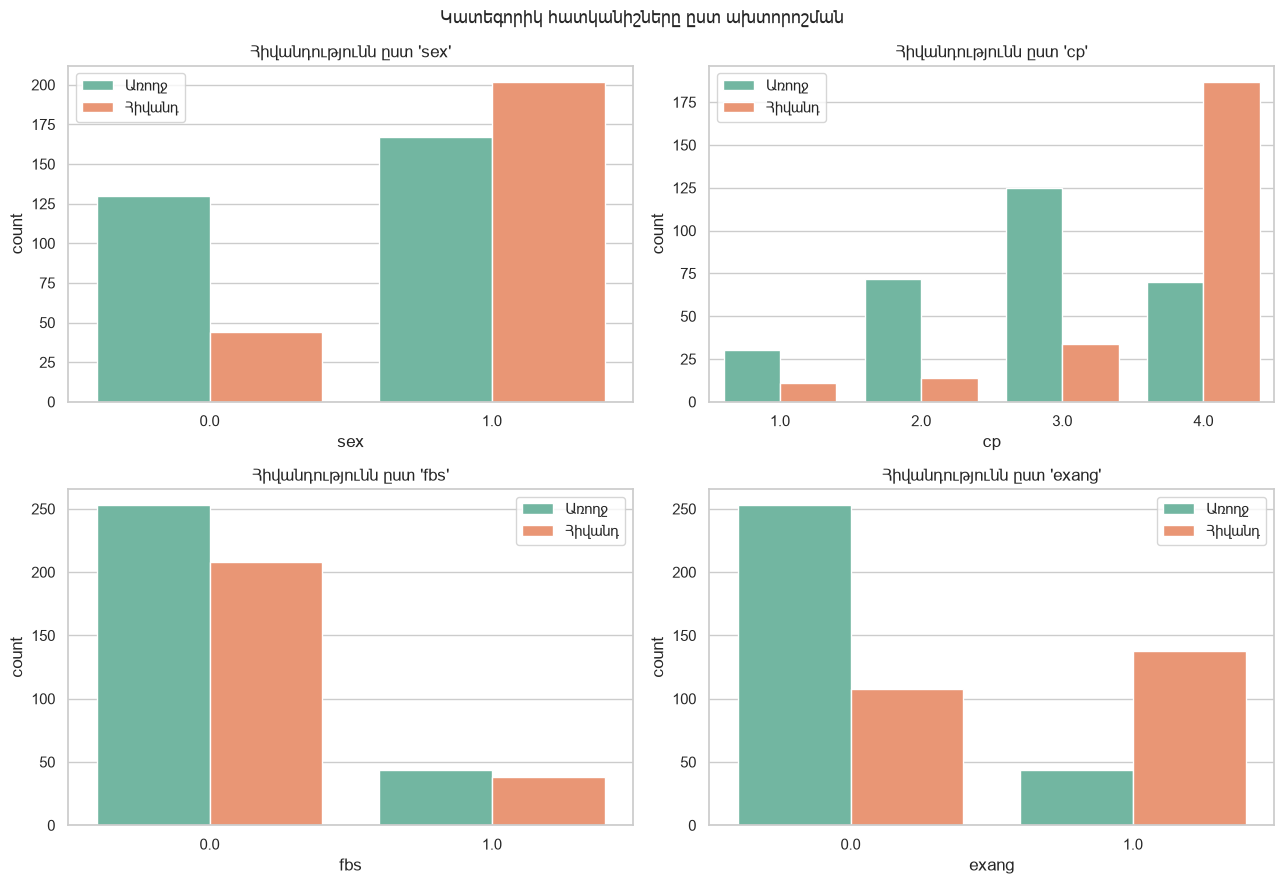

In [12]:
# Կատեգորիկ հատկանիշները ըստ հիվանդության
cat_cols = ["sex", "cp", "fbs", "exang"]
cat_labels = {
    "sex": ["Իգական", "Արական"],
    "cp": ["1", "2", "3", "4"],
    "fbs": ["Ոչ", "Այո"],
    "exang": ["Ոչ", "Այո"],
}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, x=col, hue="target", ax=ax, palette="Set2")
    ax.set_title(f"Հիվանդությունն ըստ '{col}'")
    ax.legend(["Առողջ", "Հիվանդ"], title="")
plt.suptitle("Կատեգորիկ հատկանիշները ըստ ախտորոշման", fontsize=13)
plt.tight_layout()
plt.show()

**Դիտարկում.** Արական սեռի ներկայացուցիչները, 4-րդ տիպի կրծքի ցավ ունեցողները և ֆիզ. ծանրաբեռնումից անգինա ունեցողները ավելի հաճախ հիվանդ են։

### 3.8 Ծայրահեղ արժեքների (outliers) ստուգում

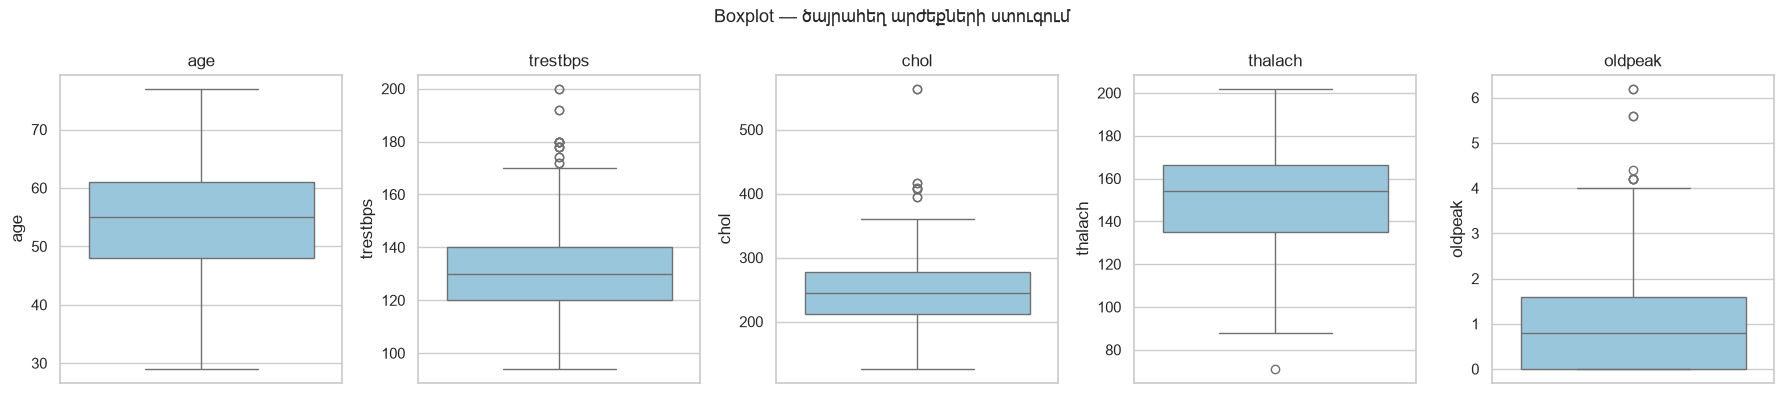

age         : 0 հնարավոր outlier (IQR կանոն)
trestbps    : 18 հնարավոր outlier (IQR կանոն)
chol        : 10 հնարավոր outlier (IQR կանոն)
thalach     : 1 հնարավոր outlier (IQR կանոն)
oldpeak     : 9 հնարավոր outlier (IQR կանոն)


In [13]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#8ecae6")
    ax.set_title(col)
plt.suptitle("Boxplot — ծայրահեղ արժեքների ստուգում", fontsize=13)
plt.tight_layout()
plt.show()

for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f"{col:12s}: {n_out} հնարավոր outlier (IQR կանոն)")

### 3.10 Կոդավորում և նորմավորում (project-synced)

Modeling մասում օգտագործում ենք `train.py`-ի նույն preprocessing ֆունկցիան (`load_and_preprocess`), որպեսզի notebook-ի train/evaluation արդյունքները 1:1 համընկնեն script-ի հետ։

### 3.9 Նոր feature-ների ստեղծում (Feature Engineering)

In [14]:
# 1) Տարիքի խումբ (նույնը train.py-ից)
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 55, 70, 120],
    labels=["young", "middle", "senior", "elderly"],
)

# 2) Բարձր ճնշում (>140)
df["high_bp"] = (df["trestbps"] > 140).astype(int)

# 3) Բարձր խոլեստերին (>240)
df["high_chol"] = (df["chol"] > 240).astype(int)

# 4) Սթրեսի ինդեքս (նույնը train.py-ից)
df["stress_index"] = df["thalach"] / (df["trestbps"] + 1)

df[["age_group", "high_bp", "high_chol", "stress_index"]].head()

,age_group,high_bp,high_chol,stress_index
0,senior,1,0,1.027397
1,senior,1,1,0.670807
2,senior,0,0,1.066116
3,young,0,1,1.427481
4,middle,0,0,1.312977


### 3.10 Կոդավորում և նորմավորում (project-synced)

Modeling մասում օգտագործում ենք `train.py`-ի նույն preprocessing ֆունկցիան (`load_and_preprocess`), որպեսզի notebook-ի train/evaluation արդյունքները 1:1 համընկնեն script-ի հետ։

In [15]:
from train import load_and_preprocess

# Canonical preprocessing from train.py
auto_X, auto_y = load_and_preprocess(DATA_PATH)
df_model = auto_X.copy()
df_model["target"] = auto_y.values

print("Project-synced shape:", df_model.shape)
print("Features:", auto_X.shape[1], "| Samples:", auto_X.shape[0])
df_model.head(3)

  Note: detected 240 duplicated rows; keeping them as requested.
Project-synced shape: (534, 20)
Features: 19 | Samples: 534


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,high_bp,high_chol,stress_index,age_group_middle,age_group_senior,age_group_elderly,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,1,0,1.027397,False,True,False,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,1,0.670807,False,True,False,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,0,0,1.066116,False,True,False,1


## 4. Մոդելի ուսուցում — Logistic Regression

### 4.1 Կախյալ և անկախ փոփոխականների սահմանում

In [16]:
X = df_model.drop(columns=["target"])  # անկախ փոփոխականներ
y = df_model["target"]                  # կախյալ փոփոխական
print("Հատկանիշներ (X):", X.shape)
print("Թիրախ      (y):", y.shape)

Հատկանիշներ (X): (534, 19)
Թիրախ      (y): (534,)


### 4.2 Տվյալների բաժանում train / test — 80% / 20%

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Նորմավորում (StandardScaler) — scaler-ը հարմարեցվում է ՄԻԱՅՆ train-ի վրա
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train չափ:", X_train.shape[0])
print("Test  չափ:", X_test.shape[0])

Train չափ: 427
Test  չափ: 107


### 4.3 Մոդելի ուսուցում, գործակիցներ և ազատ անդամ

In [18]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_sc, y_train)

print("Ազատ անդամ (intercept):", log_reg.intercept_[0].round(4))
print("\nԳործակիցներ (coefficients):")
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", ascending=False)
print(coef_df.to_string(index=False))

Ազատ անդամ (intercept): -0.1172

Գործակիցներ (coefficients):
          feature  coefficient
               ca     1.084435
             thal     0.666431
               cp     0.538311
        high_chol     0.509035
              sex     0.505558
 age_group_senior     0.441614
            exang     0.401351
         trestbps     0.367354
          oldpeak     0.345146
            slope     0.318324
          restecg     0.216069
          high_bp     0.037430
             chol    -0.009026
age_group_elderly    -0.070345
     stress_index    -0.092064
 age_group_middle    -0.282013
              fbs    -0.402583
          thalach    -0.501336
              age    -0.652211


### 4.4 Կանխատեսում test-ի վրա — Accuracy, Precision, Recall

In [19]:
y_pred_lr   = log_reg.predict(X_test_sc)
y_proba_lr  = log_reg.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr,
      target_names=["Առողջ", "Հիվանդ"]))

=== Logistic Regression ===
Accuracy : 0.8785
Precision: 0.9091
Recall   : 0.8163
F1-score : 0.8602

              precision    recall  f1-score   support

       Առողջ       0.86      0.93      0.89        58
      Հիվանդ       0.91      0.82      0.86        49

    accuracy                           0.88       107
   macro avg       0.88      0.87      0.88       107
weighted avg       0.88      0.88      0.88       107



### 4.5 Շփոթության մատրից (Confusion Matrix)

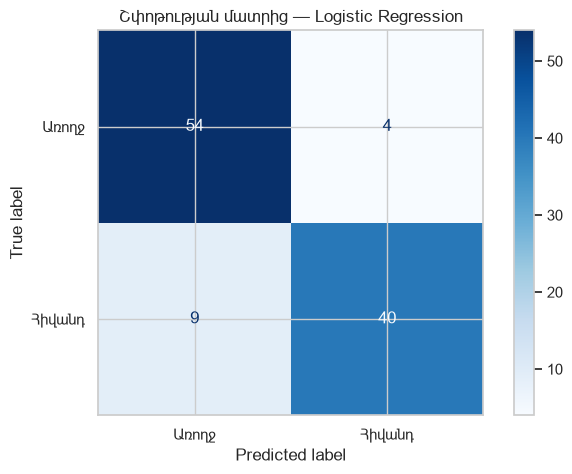

In [20]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["Առողջ", "Հիվանդ"]).plot(cmap="Blues")
plt.title("Շփոթության մատրից — Logistic Regression")
plt.show()

### 4.6 Ամենաազդեցիկ հատկանիշները (գործակիցների վիզուալիզացիա)

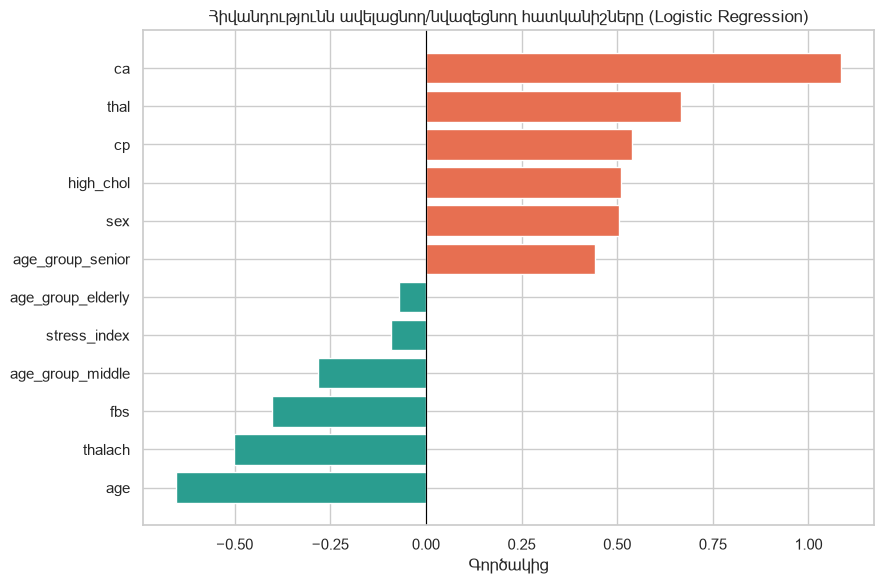

In [21]:
top = pd.concat([coef_df.head(6), coef_df.tail(6)])
colors = ["#e76f51" if c > 0 else "#2a9d8f" for c in top["coefficient"]]
plt.figure(figsize=(9, 6))
plt.barh(top["feature"], top["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Հիվանդությունն ավելացնող/նվազեցնող հատկանիշները (Logistic Regression)")
plt.xlabel("Գործակից")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Մոդելի ուսուցում — KNN

### 5.1 KNN-ի համար project-fixed `k=13` (train.py-ի համահունչ)

Project-fixed k = 13
k=13-ի test F1 = 0.7907


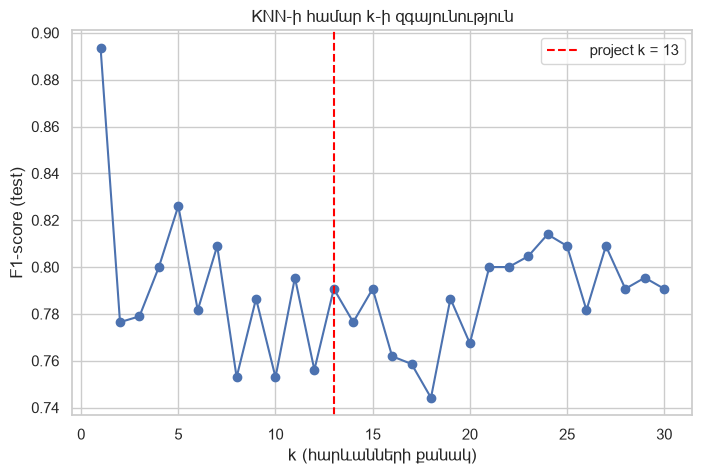

In [22]:
# train.py-ի համահունչ՝ KNN-ը օգտագործում ենք k=13
best_k = 13

# Ցույց ենք տալիս նաև test F1-ը տարբեր k-ների դեպքում (լրացուցիչ վերլուծություն)
k_values = range(1, 31)
f1_scores_k = []
for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_sc, y_train)
    f1_scores_k.append(f1_score(y_test, knn_tmp.predict(X_test_sc)))

print(f"Project-fixed k = {best_k}")
print(f"k=13-ի test F1 = {f1_scores_k[12]:.4f}")

plt.plot(list(k_values), f1_scores_k, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"project k = {best_k}")
plt.xlabel("k (հարևանների քանակ)")
plt.ylabel("F1-score (test)")
plt.title("KNN-ի համար k-ի զգայունություն")
plt.legend()
plt.show()

### 5.2 KNN ուսուցում, կանխատեսում, Accuracy, Precision, Recall

In [24]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)

y_pred_knn  = knn.predict(X_test_sc)
y_proba_knn = knn.predict_proba(X_test_sc)[:, 1]

print(f"=== KNN (k={best_k}) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_knn):.4f}")
print()
print(classification_report(y_test, y_pred_knn,
      target_names=["Առողջ", "Հիվանդ"]))

=== KNN (k=13) ===
Accuracy : 0.8318
Precision: 0.9189
Recall   : 0.6939
F1-score : 0.7907

              precision    recall  f1-score   support

       Առողջ       0.79      0.95      0.86        58
      Հիվանդ       0.92      0.69      0.79        49

    accuracy                           0.83       107
   macro avg       0.85      0.82      0.83       107
weighted avg       0.85      0.83      0.83       107



### 5.3 Շփոթության մատրից — KNN

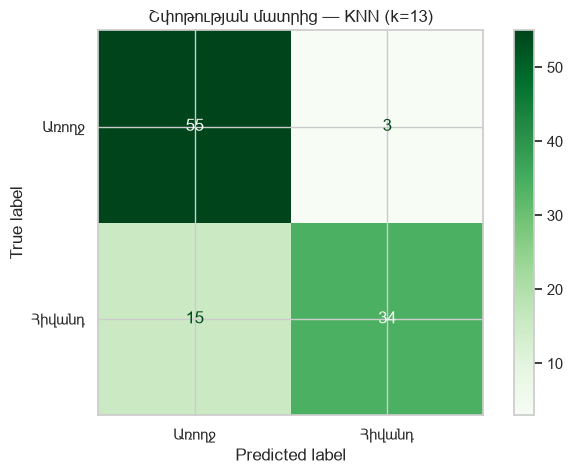

In [25]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=["Առողջ", "Հիվանդ"]).plot(cmap="Greens")
plt.title(f"Շփոթության մատրից — KNN (k={best_k})")
plt.show()

## 6. Հավելյալ աշխատանք

### 6.1 4 մոդելի համեմատություն (Logistic, KNN, Random Forest, Gradient Boosting)

In [26]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    f"KNN (k={best_k})": KNeighborsClassifier(n_neighbors=best_k),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

rows = []
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)
    proba = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, "predict_proba") else None

    cv = cross_val_score(
        model,
        X_train_sc,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="f1",
    )

    rows.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred),
            "F1": f1_score(y_test, pred),
            "ROC-AUC": roc_auc_score(y_test, proba) if proba is not None else np.nan,
            "CV-F1 Mean": cv.mean(),
            "CV-F1 Std": cv.std(),
        }
    )

results = pd.DataFrame(rows).set_index("Model").round(4)
best_model_name = results["CV-F1 Mean"].idxmax()

print(f"Լավագույն մոդել (CV-F1-ով): {best_model_name}")
results.sort_values("CV-F1 Mean", ascending=False)

Լավագույն մոդել (CV-F1-ով): Gradient Boosting


,Accuracy,Precision,Recall,F1,ROC-AUC,CV-F1 Mean,CV-F1 Std
Model,,,,,,,
Gradient Boosting,0.9626,1.0000,0.9184,0.9574,0.9743,0.8941,0.0328
Random Forest,0.9439,0.9574,0.9184,0.9375,0.9870,0.8939,0.0396
Logistic Regression,0.8785,0.9091,0.8163,0.8602,0.9462,0.8254,0.0524
KNN (k=13),0.8318,0.9189,0.6939,0.7907,0.9272,0.8182,0.0637


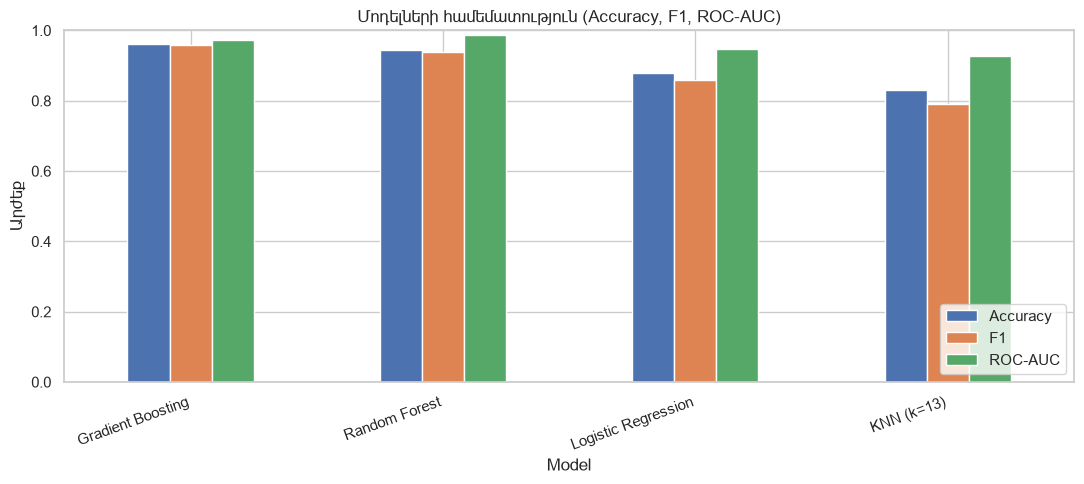

In [27]:
results[["Accuracy", "F1", "ROC-AUC"]].sort_values("F1", ascending=False).plot(
    kind="bar", figsize=(11, 5)
)
plt.title("Մոդելների համեմատություն (Accuracy, F1, ROC-AUC)")
plt.ylabel("Արժեք")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.2 ROC կորեր

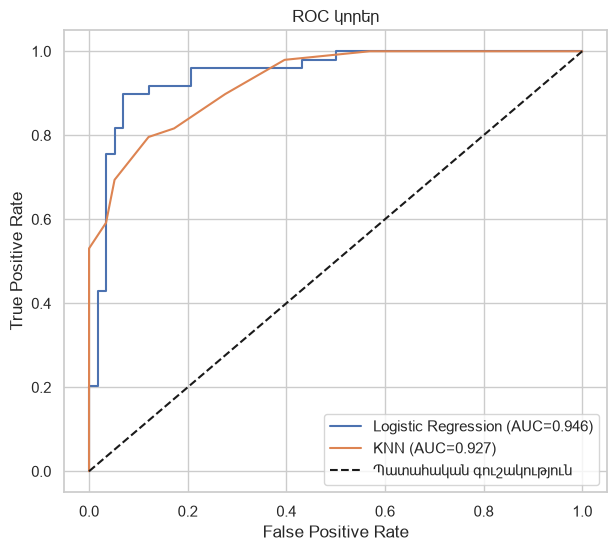

In [28]:
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_proba_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr,  tpr_lr,  label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={roc_auc_score(y_test, y_proba_knn):.3f})")
plt.plot([0,1],[0,1],"k--", label="Պատահական գուշակություն")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC կորեր")
plt.legend(loc="lower right")
plt.show()

### 6.3 Cross-validation (5-ֆոլդ)

In [29]:
print("5-fold Cross-validation (F1)՝")
cv_view = results[["CV-F1 Mean", "CV-F1 Std"]].sort_values("CV-F1 Mean", ascending=False)
print(cv_view.to_string())

5-fold Cross-validation (F1)՝
                     CV-F1 Mean  CV-F1 Std
Model                                     
Gradient Boosting        0.8941     0.0328
Random Forest            0.8939     0.0396
Logistic Regression      0.8254     0.0524
KNN (k=13)               0.8182     0.0637


### 6.4 Հիպերպարամետրերի կարգաբերում — GridSearchCV (KNN)

In [30]:
param_grid = {
    "n_neighbors": [3, 5, 7, 11, 15, 21],
    "weights"    : ["uniform", "distance"],
    "p"          : [1, 2],   # 1=Manhattan, 2=Euclidean
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train_sc, y_train)

print("Լավագույն պարամետրեր:", grid.best_params_)
print("Լավագույն CV F1:      ", round(grid.best_score_, 4))

y_pred_tuned = grid.best_estimator_.predict(X_test_sc)
print(f"\nԿարգաբերված KNN-ն test-ի վրա:")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_tuned):.4f}")

Լավագույն պարամետրեր: {'n_neighbors': 21, 'p': 2, 'weights': 'distance'}
Լավագույն CV F1:       0.9115

Կարգաբերված KNN-ն test-ի վրա:
Accuracy : 0.9159
Precision: 0.9545
Recall   : 0.8571
F1-score : 0.9032


## 7. Եզրակացություններ

**Տվյալների մասին**
- Տվյալները մաքրվեցին train.py-ի նույն կանոններով (թվայնացում, missing handling, target binarization, feature engineering):
  - `age_group`, `high_bp`, `high_chol`, `stress_index`
- Կրկնվող տողերը պահվում են (train.py-ի վարքի համահունչ)։
- Բժշկական ծայրահեղ արժեքները չեն հեռացվում մեխանիկորեն, որպեսզի չկորցնենք կարևոր կլինիկական ինֆորմացիան։

**Մոդելների մասին**
- Պարտադիր բաժինը (Logistic Regression, KNN) ամբողջությամբ կատարված է՝ metrics + confusion matrix + վիզուալիզացիա։
- Լրացուցիչ մասում համեմատված են նաև Random Forest և Gradient Boosting։
- Լավագույն մոդելը ընտրվում է `CV-F1 Mean`-ով, ինչը ավելի կայուն մոտեցում է, քան միայն մեկ train/test բաժանումը։

**Ինչու է այս notebook-ը համընկնում նախագծի հետ**
- Օգտագործում է նույն dataset path-ը (`data/heart_disease.csv`)։
- Preprocessing-ը և feature engineering-ը համընկնում են `train.py`-ի տրամաբանության հետ։
